In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

import warnings

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")

In [70]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel(list(uploaded.keys())[0])
df.head()

Saving Jhansi_Rope_Store_ (1).xlsx to Jhansi_Rope_Store_ (1) (2).xlsx


,Order_Number,Date,Customer_ID,Customer_Name,Customer_Type,Product_ID_SKU,Product_Category,Product_Type,Variety,Quantity_Sold,Unit,Unit_Price_Rs,Total_Sale_Value_Rs,Cost_Price_Per_Unit_Rs,Total_Cost_Price_Rs,Profit_Rs,Profit_Margin_Pct,Location,Area_Type,Festival_Event
0,ORD1000,2025-07-20,C005,Sharma Enterprises,Wholesale,P004,Rope,Rope - Plastic Rp,Plastic Rp,77,Kg,62,4774,59.0,4543.0,231.0,4.84,Babina,Semi-Urban,Regular
1,ORD1001,2025-07-20,C011,Local Market,Retail,P010,Sutli,Sutli - Plastic,Plastic,9,Kg,106,954,95.0,855.0,99.0,10.38,Mandi Bangalow,Rural,Regular
2,ORD1002,2025-07-20,C004,Gupta Store,Wholesale,P004,Rope,Rope - Plastic Rp,Plastic Rp,137,Kg,62,8494,59.0,8083.0,411.0,4.84,Guara,Rural,Regular
3,ORD1003,2025-07-20,C004,Gupta Store,Wholesale,P009,Wiper,Wiper - Standard,Standard,88,Piece,50,4400,47.5,4180.0,220.0,5.00,Mandi Bangalow,Rural,Regular
4,ORD1004,2025-07-21,C001,Swastik Enterprises,Wholesale,P003,Niwar,Niwar - Polyester,Polyester,114,Kg,135,15390,129.0,14706.0,684.0,4.44,Talbehat,Rural,Regular


In [71]:
# Copy dataframe for safety
df_clean = df.copy()

# Standardize column names (already clean)
df_clean.columns = df_clean.columns.str.strip()

# Convert to lowercase for categorical consistency
df_clean["Customer_Type"] = df_clean["Customer_Type"].str.lower()
df_clean["Area_Type"] = df_clean["Area_Type"].str.lower()
df_clean["Product_Type"] = df_clean["Product_Type"].str.lower()

# Convert Date column
df_clean["Date"] = pd.to_datetime(df_clean["Date"])
df_clean = df_clean.sort_values("Date")

In [72]:
# Revenue & cost already provided
df_clean["Revenue"] = df_clean["Total_Sale_Value_Rs"]
df_clean["COGS"] = df_clean["Total_Cost_Price_Rs"]
df_clean["Profit"] = df_clean["Profit_Rs"]
df_clean["Margin"] = df_clean["Profit_Margin_Pct"] / 100


In [73]:
daily_sales = df_clean.groupby("Date")["Revenue"].sum()
daily_sales

,Revenue
Date,
2025-07-20,18622
2025-07-21,57197
2025-07-23,44402
2025-07-24,27231
2025-07-25,29644
...,...
2025-10-23,80373
2025-10-24,60620
2025-10-25,60810


SARIMA


Initial ADF p-value: 0.4635
--- Validation Metrics ---
MAE: 15582.14 | RMSE: 19668.27 | Accuracy: -inf%


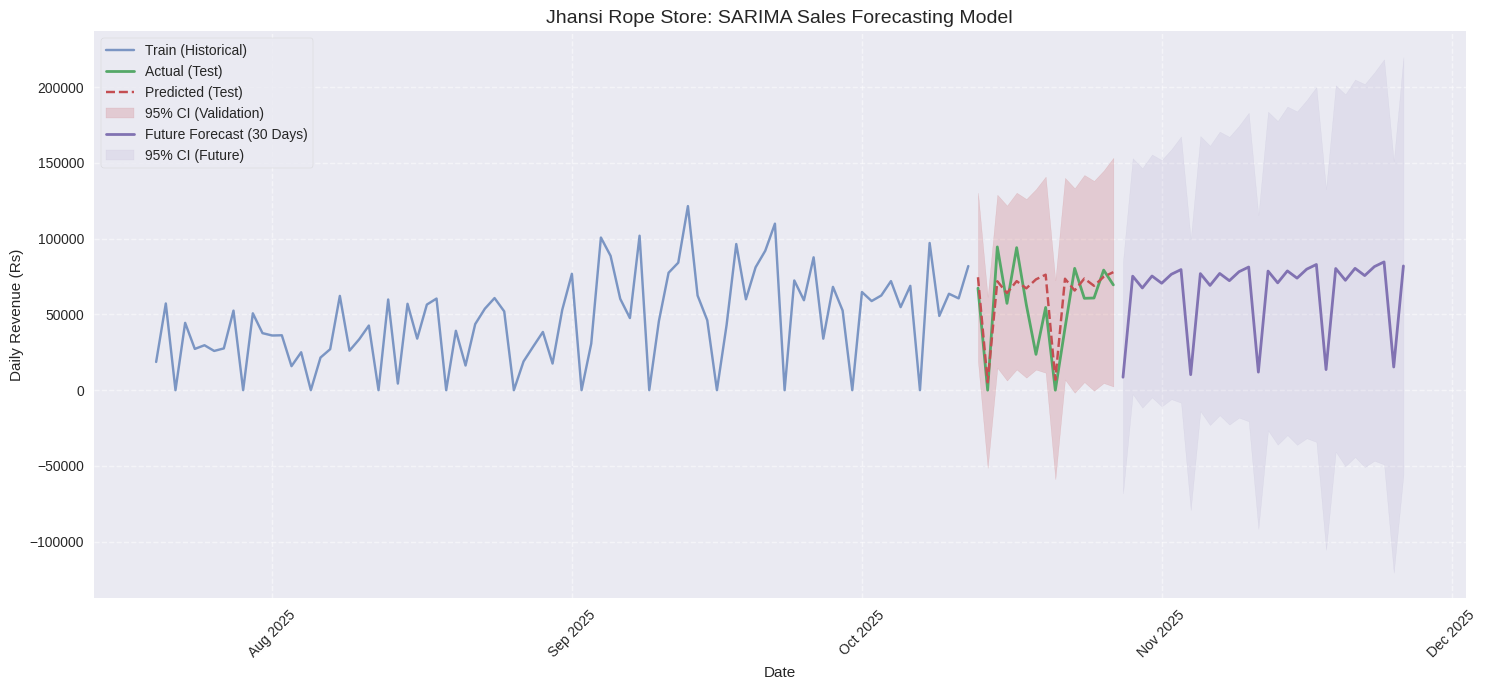

In [74]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools
import numpy as np

# --- 1. PREPARATION: Ensure daily frequency ---
# Your original series had gaps in dates; we must fill them with 0 for SARIMA
daily_sales = daily_sales.asfreq('D', fill_value=0)

# --- 2. STATIONARITY CHECK (ADF Test) ---
result = adfuller(daily_sales)
print(f'Initial ADF p-value: {result[1]:.4f}')

# --- 3. TRAIN/TEST SPLIT ---
test_days = 15
train = daily_sales[:-test_days]
test = daily_sales[-test_days:]

# --- 4. OPTIMIZED GRID SEARCH (Handling non-stationarity) ---
# We force d=1 and D=1 because your p-value (0.15) was > 0.05
p = q = range(0, 2)
d = [1]
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], 1, x[2], 7) for x in list(itertools.product(p, d, q))]

best_aic = float("inf")
best_params = None
best_seasonal = None

for param in pdq:
    for s_param in seasonal_pdq:
        try:
            mod = SARIMAX(train, order=param, seasonal_order=s_param,
                          enforce_stationarity=False, enforce_invertibility=False)
            results = mod.fit(disp=False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_params = param
                best_seasonal = s_param
        except: continue

# --- 5. FINAL MODEL & FORECASTING ---
model_final = SARIMAX(train, order=best_params, seasonal_order=best_seasonal)
model_fit = model_final.fit(disp=False)

# Validation Forecast (Testing)
forecast_obj = model_fit.get_forecast(steps=len(test))
pred_mean = forecast_obj.predicted_mean
pred_ci = forecast_obj.conf_int()

# Future Forecast (Next 30 Days)
fc_obj = model_fit.get_forecast(steps=len(test) + 30)
fc_mean = fc_obj.predicted_mean[-30:]
fc_ci = fc_obj.conf_int().iloc[-30:]

# --- 6. ACCURACY METRICS ---
mae = mean_absolute_error(test, pred_mean)
rmse = np.sqrt(mean_squared_error(test, pred_mean))
mape = np.mean(np.abs((test - pred_mean) / test)) * 100
print(f"--- Validation Metrics ---\nMAE: {mae:.2f} | RMSE: {rmse:.2f} | Accuracy: {100-mape:.2f}%")

# --- 7. PROFESSIONAL VISUALIZATION (Fixed Axis) ---
plt.figure(figsize=(15, 7))

# Plotting
plt.plot(train.index, train, label='Train (Historical)', color='C0', alpha=0.7)
plt.plot(test.index, test, label='Actual (Test)', color='C1', linewidth=2)
plt.plot(pred_mean.index, pred_mean, label='Predicted (Test)', color='C2', linestyle='--')
plt.fill_between(pred_ci.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], color='C2', alpha=0.2, label='95% CI (Validation)')

plt.plot(fc_mean.index, fc_mean, label='Future Forecast (30 Days)', color='C3', linewidth=2)
plt.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], color='C3', alpha=0.1, label='95% CI (Future)')

# FIXED: Monthly/Weekly Axis Formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.title('Jhansi Rope Store: SARIMA Sales Forecasting Model', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Daily Revenue (Rs)')
plt.legend(loc='upper left', frameon=True)
plt.grid(True, which='major', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [75]:
from statsmodels.tsa.stattools import adfuller

# 1. Run the Augmented Dickey-Fuller test
# Assuming 'daily_sales' is your aggregated Series with Date as index
result = adfuller(daily_sales.dropna())

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

if result[1] <= 0.05:
    print("Result: Data is stationary (Ready for SARIMA)")
else:
    print("Result: Data is non-stationary (Needs differencing)")

ADF Statistic: -1.637597
p-value: 0.463517
Result: Data is non-stationary (Needs differencing)


In [76]:
# 1. Apply differencing (Today's Sales - Yesterday's Sales)
daily_sales_diff = daily_sales.diff().dropna()

# 2. Re-run the ADF test on the differenced data
print("--- Re-checking Stationarity after Differencing ---")
result_diff = adfuller(daily_sales_diff)
print(f'ADF Statistic: {result_diff[0]}')
print(f'p-value: {result_diff[1]}')

if result_diff[1] <= 0.05:
    print("Result: Data is now stationary! You can proceed to modeling.")
else:
    print("Result: Still non-stationary. Try seasonal differencing: .diff(7)")

--- Re-checking Stationarity after Differencing ---
ADF Statistic: -11.867270816927165
p-value: 6.62996394100222e-22
Result: Data is now stationary! You can proceed to modeling.


In [77]:
# Split: 80% for training, 20% for testing
train_size = int(len(daily_sales) * 0.8)
train, test = daily_sales[0:train_size], daily_sales[train_size:]

print(f"Total observations: {len(daily_sales)}")
print(f"Training set: {len(train)} days")
print(f"Testing set: {len(test)} days")

Total observations: 100
Training set: 80 days
Testing set: 20 days


In [78]:
import itertools
import warnings
warnings.filterwarnings("ignore")

# Define ranges for p, d, q (keep them small to save time)
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 7) for x in list(itertools.product(p, d, q))] # 7 for weekly seasonality

best_aic = float("inf")
best_params = None
best_seasonal_params = None

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            temp_model = SARIMAX(train, order=param, seasonal_order=param_seasonal)
            results = temp_model.fit(disp=False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_params = param
                best_seasonal_params = param_seasonal
        except:
            continue

print(f'Best SARIMA Order: {best_params} x {best_seasonal_params} with AIC: {best_aic}')

Best SARIMA Order: (0, 1, 1) x (0, 1, 1, 7) with AIC: 1662.7766077671004


In [79]:
# Fit the best model
final_model = SARIMAX(train, order=best_params, seasonal_order=best_seasonal_params)
model_fit = final_model.fit(disp=False)

# Forecast the next 'n' steps (length of test set)
forecast_obj = model_fit.get_forecast(steps=len(test))
forecast_values = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int() # Confidence intervals for the shaded area

In [80]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test, forecast_values)
rmse = np.sqrt(mean_squared_error(test, forecast_values))
mape = np.mean(np.abs((test - forecast_values) / test)) * 100

print(f"--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Accuracy (100 - MAPE): {100 - mape:.2f}%")

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 14215.58
Root Mean Squared Error (RMSE): 19229.90
Accuracy (100 - MAPE): -inf%


In [81]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
daily = df.groupby('Date')['Total_Sale_Value_Rs'].sum().rename('daily_sales').to_frame()
# Ensure daily frequency (fills missing dates with 0 sales — change if you prefer NaN)
daily = daily.asfreq('D', fill_value=0)
series = daily['daily_sales']

# Train/test split
test_days = 18
if len(series) < test_days + 10:
    raise ValueError("Not enough days for requested test split. Reduce test_days or use more data.")
train = series.iloc[:-test_days]
test = series.iloc[-test_days:]

print(f"Series from {series.index.min().date()} to {series.index.max().date()} (n={len(series)})")
print(f"Train length: {len(train)}, Test length: {len(test)}")

Series from 2025-07-20 to 2025-10-27 (n=100)
Train length: 82, Test length: 18


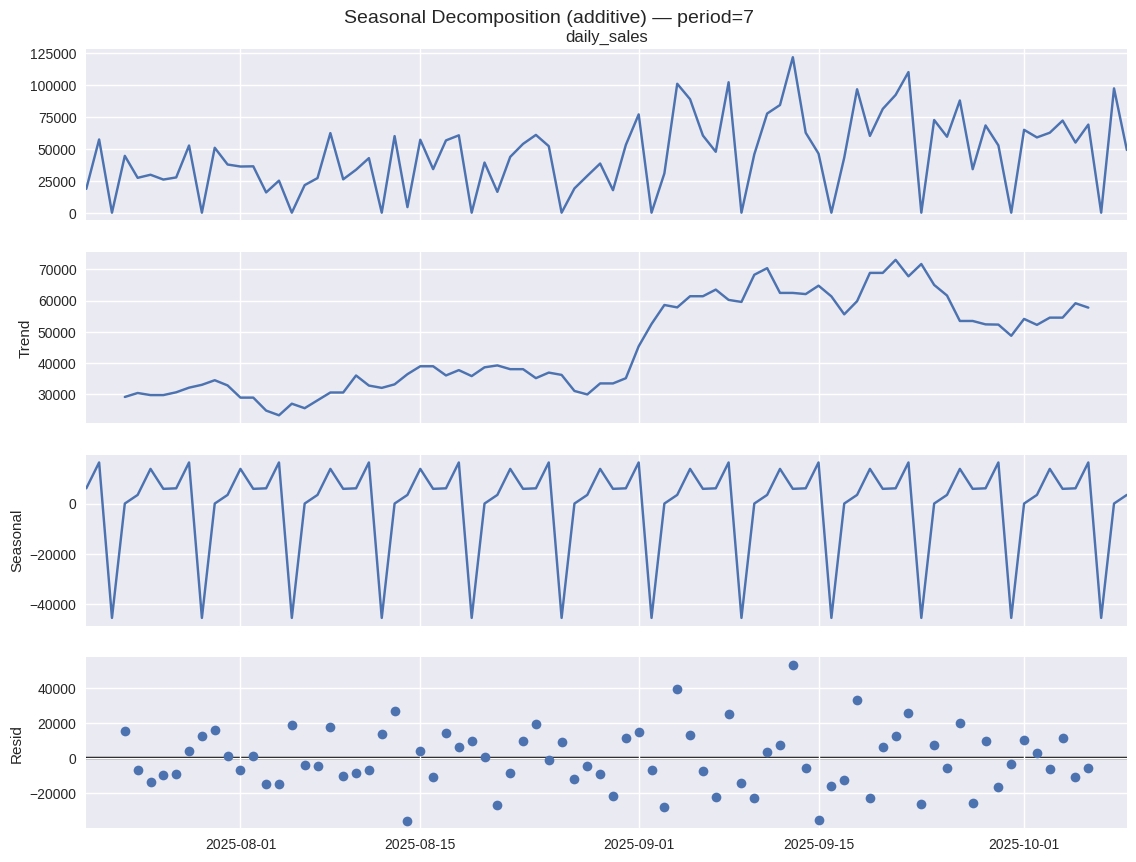

In [82]:
# Seasonal decomposition (period=7)

plt.rcParams.update({'figure.autolayout': True})
decomp = seasonal_decompose(train, model='additive', period=7)
fig = decomp.plot()
fig.set_size_inches(12,9)
plt.suptitle('Seasonal Decomposition (additive) — period=7', fontsize=14)
plt.show()

In [83]:
# Fit SARIMA model (1,1,1)(1,1,1,7)

order = (1,1,1)
seasonal_order = (1,1,1,7)
model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False)
res = model.fit(disp=False, maxiter=300)
print(res.summary())

                                     SARIMAX Results                                     
Dep. Variable:                       daily_sales   No. Observations:                   82
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -748.754
Date:                           Mon, 12 Jan 2026   AIC                           1507.509
Time:                                   16:56:02   BIC                           1518.381
Sample:                               07-20-2025   HQIC                          1511.798
                                    - 10-09-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0056      0.244      0.023      0.982      -0.472       0.483
ma.L1         -0.8786      0.107     -8.174

In [84]:
# Forecast on test period + 30-day forecast

# Predictions for the test period
pred_test = res.get_forecast(steps=len(test))
pred_mean = pred_test.predicted_mean
pred_ci = pred_test.conf_int(alpha=0.05)

# Forecast horizon (30 days) beyond train end
forecast_horizon = 30
fc = res.get_forecast(steps=forecast_horizon)
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int(alpha=0.05)

In [85]:
# Forecast metrics

mae = mean_absolute_error(test, pred_mean)
mse = mean_squared_error(test, pred_mean)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - pred_mean) / np.where(test==0, 1, test))) * 100

print("\nForecast metrics on test set:")
print(f"MAE = {mae:,.2f}")
print(f"RMSE = {rmse:,.2f}")
print(f"MAPE = {mape:.4f}%")



Forecast metrics on test set:
MAE = 15,274.73
RMSE = 18,255.95
MAPE = 83980.0946%


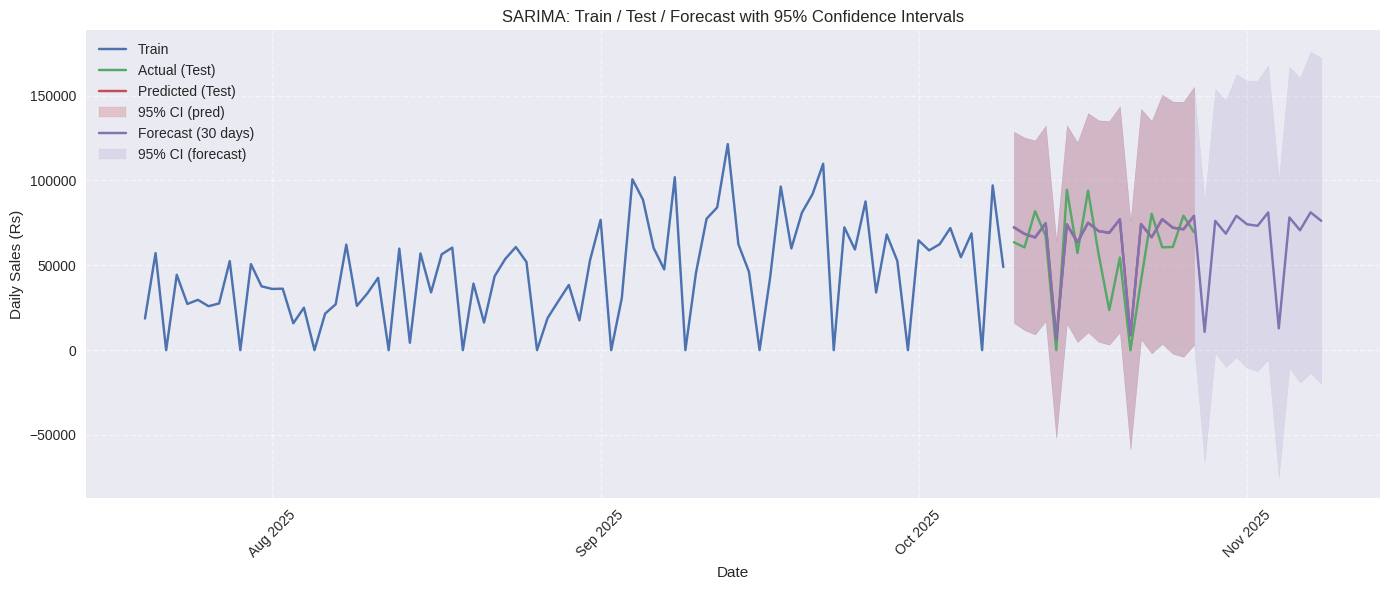

In [86]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Use your professional plot with the added axis fix
plt.figure(figsize=(14,6))

# 1. Plotting your variables
plt.plot(train.index, train, label='Train', color='C0')
plt.plot(test.index, test, label='Actual (Test)', color='C1')
plt.plot(pred_mean.index, pred_mean, label='Predicted (Test)', color='C2')
plt.fill_between(pred_ci.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], color='C2', alpha=0.25, label='95% CI (pred)')

plt.plot(fc_mean.index, fc_mean, label='Forecast (30 days)', color='C3')
plt.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], color='C3', alpha=0.15, label='95% CI (forecast)')

# 2. THE AXIS FIX: Force Monthly labels instead of Yearly
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())    # Major ticks: Every month
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=7)) # Minor ticks: Every week
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) # Format: "Oct 2025"

plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.title('SARIMA: Train / Test / Forecast with 95% Confidence Intervals')
plt.xlabel('Date')
plt.ylabel('Daily Sales (Rs)')
plt.grid(True, which='major', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

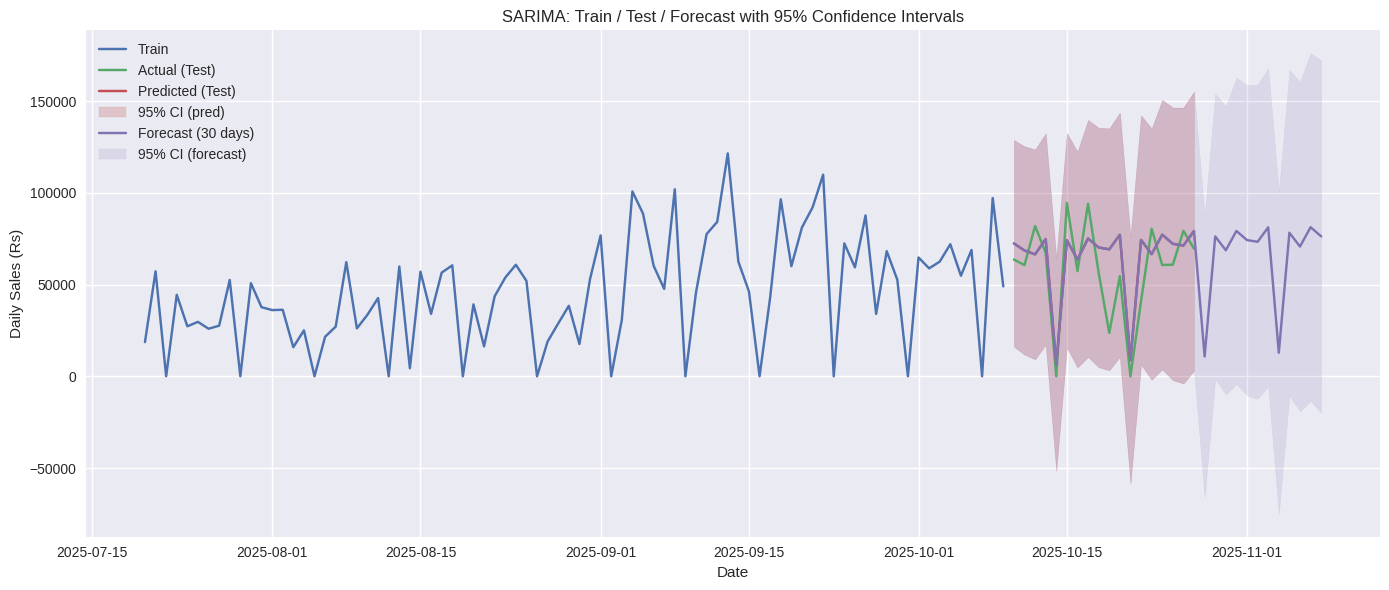

In [87]:
# Plot Train/Test/Forecast with 95% CI

plt.figure(figsize=(14,6))
plt.plot(train.index, train, label='Train', color='C0')
plt.plot(test.index, test, label='Actual (Test)', color='C1')
plt.plot(pred_mean.index, pred_mean, label='Predicted (Test)', color='C2')
plt.fill_between(pred_ci.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], color='C2', alpha=0.25, label='95% CI (pred)')
plt.plot(fc_mean.index, fc_mean, label='Forecast (30 days)', color='C3')
plt.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], color='C3', alpha=0.15, label='95% CI (forecast)')
plt.legend()
plt.title('SARIMA: Train / Test / Forecast with 95% Confidence Intervals')
plt.xlabel('Date')
plt.ylabel('Daily Sales (Rs)')
plt.show()

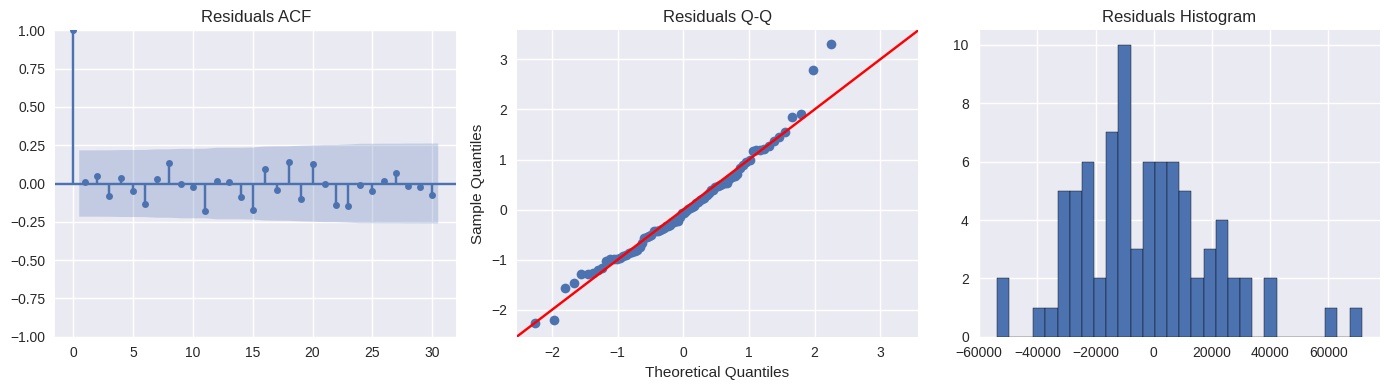

In [88]:
# Residual diagnostics

residuals = res.resid

plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plot_acf(residuals.dropna(), ax=plt.gca(), lags=30)
plt.title('Residuals ACF')

plt.subplot(1,3,2)
sm.qqplot(residuals.dropna(), line='45', ax=plt.gca(), fit=True)
plt.title('Residuals Q-Q')

plt.subplot(1,3,3)
plt.hist(residuals.dropna(), bins=30, edgecolor='k')
plt.title('Residuals Histogram')

plt.tight_layout()
plt.show()


Ljung-Box test results (lb_stat, lb_pvalue):
      lb_stat  lb_pvalue
10   4.501448   0.921904
15  11.575878   0.710806
20  17.742646   0.604357

Residuals summary:
count       82.0000
mean     -2985.2048
std      22695.1521
min     -53940.6530
25%     -19410.4169
50%      -4620.0735
75%       8935.4093
max      71456.3092
dtype: float64


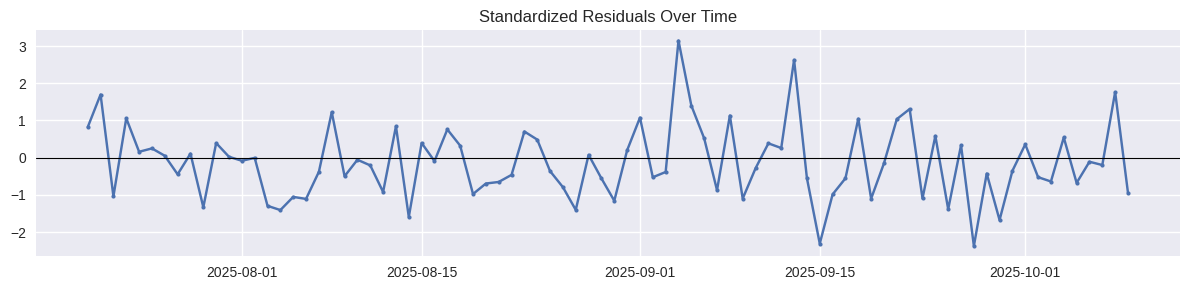

In [89]:
# Ljung-Box test (checks for remaining autocorrelation)
lb = acorr_ljungbox(residuals.dropna(), lags=[10,15,20], return_df=True)
print("\nLjung-Box test results (lb_stat, lb_pvalue):")
print(lb[['lb_stat','lb_pvalue']])

# Residual summary
print("\nResiduals summary:")
print(residuals.describe().round(4))

# Optional: standardized residual plot
std_resid = residuals / residuals.std()
plt.figure(figsize=(12,3))
plt.plot(std_resid.index, std_resid, marker='o', markersize=3, linestyle='-')
plt.axhline(0, color='k', linewidth=0.8)
plt.title('Standardized Residuals Over Time')
plt.show()


K Mean


In [90]:
# Frequency: unique orders per customer (use Order_Number if available)
if 'Order_Number' in df.columns:
    freq = df.groupby("Customer_Name")['Order_Number'].nunique()
else:
    freq = df.groupby("Customer_Name").size()

In [91]:
# Average bill, average margin (use Profit_Margin_Pct as percent), total revenue, avg quantity
avg_bill = df.groupby("Customer_Name")['Total_Sale_Value_Rs'].mean()
avg_margin = df.groupby("Customer_Name")['Profit_Margin_Pct'].mean()
total_revenue = df.groupby("Customer_Name")['Total_Sale_Value_Rs'].sum()
avg_quantity = df.groupby("Customer_Name")['Quantity_Sold'].mean()

In [92]:
# Mode of area and customer type
area_pref = df.groupby("Customer_Name")['Area_Type'].agg(lambda x: x.mode().iloc[0] if len(x.mode())>0 else np.nan)
custtype_pref = df.groupby("Customer_Name")['Customer_Type'].agg(lambda x: x.mode().iloc[0] if len(x.mode())>0 else np.nan)


In [93]:
# Build customer dataframe
cust = pd.DataFrame({
    "Customer_Name": avg_bill.index,
    "frequency": freq,
    "avg_bill": avg_bill,
    "avg_margin_pct": avg_margin,
    "total_revenue": total_revenue,
    "avg_quantity": avg_quantity,
    "area_type": area_pref,
    "customer_type": custtype_pref
}).reset_index(drop=True)

In [94]:
# Fill missing numeric values with 0 (if any)
cust[['frequency','avg_bill','avg_margin_pct','total_revenue','avg_quantity']] = cust[['frequency','avg_bill','avg_margin_pct','total_revenue','avg_quantity']].fillna(0)

display(cust.head())

,Customer_Name,frequency,avg_bill,avg_margin_pct,total_revenue,avg_quantity,area_type,customer_type
0,Convenience Shop,50,2242.620000,9.697800,112131,26.380000,Rural,Retail
1,General Store,60,2345.800000,9.918000,140748,24.983333,Rural,Retail
2,Gupta Store,59,9400.440678,4.642373,554626,109.915254,Rural,Wholesale
3,Household Supplies,51,2507.470588,9.981765,127881,28.274510,Rural,Retail
4,Kartik Sales,43,10058.581395,4.575814,432519,116.697674,Rural,Wholesale


In [95]:
# Encoding categorical fields for clustering
# ---------------------------
le_area = LabelEncoder()
le_cust = LabelEncoder()
cust['area_enc'] = le_area.fit_transform(cust['area_type'].astype(str))
cust['custtype_enc'] = le_cust.fit_transform(cust['customer_type'].astype(str))


In [96]:
features = ['frequency','avg_bill','avg_margin_pct','total_revenue','avg_quantity','area_enc','custtype_enc']
X = cust[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

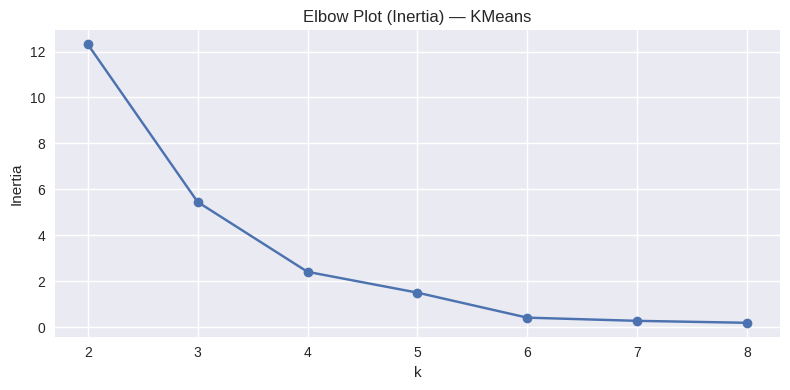

In [97]:
# Elbow plot (inertia) for k in 2..8
# ---------------------------
inertia = []
Ks = range(2,9)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(list(Ks), inertia, marker='o')
plt.title("Elbow Plot (Inertia) — KMeans")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


In [98]:
# Silhouette scores
# ---------------------------
print("Silhouette scores (k=2..8):")
for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    print(f"  k={k}: silhouette = {sil:.4f}")


Silhouette scores (k=2..8):
  k=2: silhouette = 0.7275
  k=3: silhouette = 0.6232
  k=4: silhouette = 0.6473
  k=5: silhouette = 0.6016
  k=6: silhouette = 0.6108
  k=7: silhouette = 0.5277
  k=8: silhouette = 0.3977


In [99]:
# Fit final KMeans (change best_k if you prefer)
# ---------------------------
best_k = 6   # adjust after inspecting elbow & silhouette
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=15)
cust['cluster'] = kmeans.fit_predict(X_scaled)

print("\nCluster counts:")
print(cust['cluster'].value_counts().sort_index())



Cluster counts:
cluster
0    1
1    2
2    2
3    3
4    2
5    2
Name: count, dtype: int64


In [100]:
# Cluster profile (original scale)

profile = cust.groupby('cluster')[['frequency','avg_bill','avg_margin_pct','total_revenue','avg_quantity']].mean().round(2)
print("\nCluster profile (mean values):")
display(profile)




Cluster profile (mean values):


,frequency,avg_bill,avg_margin_pct,total_revenue,avg_quantity
cluster,,,,,
0,43.00,10058.58,4.58,432519.0,116.70
1,59.00,2405.07,9.95,141840.0,25.67
2,58.50,9802.20,4.66,573228.0,112.24
3,54.33,10380.71,4.61,563872.0,111.82
4,50.50,2375.05,9.84,120006.0,27.33
5,49.00,9899.40,4.64,485385.5,107.76


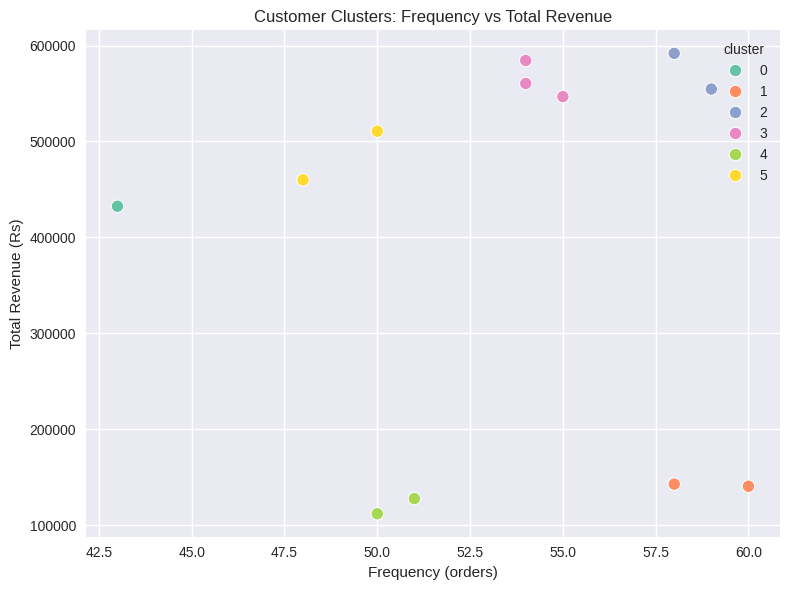

In [101]:
# 2D visualization: frequency vs total_revenue
# ---------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(data=cust, x='frequency', y='total_revenue', hue='cluster', palette='Set2', s=80)
plt.title("Customer Clusters: Frequency vs Total Revenue")
plt.xlabel("Frequency (orders)")
plt.ylabel("Total Revenue (Rs)")
plt.legend(title='cluster')
plt.show()


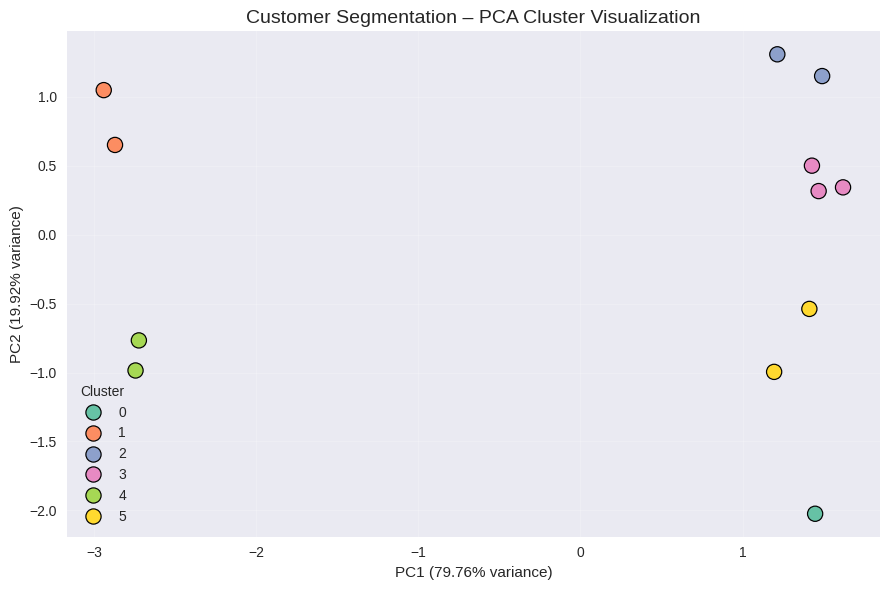

Explained Variance:
[0.79755978 0.19920334]


In [102]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Features used for clustering
features = ['frequency','avg_bill','avg_margin_pct','total_revenue','avg_quantity']

# Standardize again to ensure consistency
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cust[features])

# Apply PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

cust['PC1'] = pca_components[:,0]
cust['PC2'] = pca_components[:,1]

# Plot
plt.figure(figsize=(9,6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',
    data=cust,
    palette='Set2',
    s=120,
    edgecolor='black'
)

plt.title("Customer Segmentation – PCA Cluster Visualization", fontsize=14)
plt.xlabel(f"PC1 ({round(pca.explained_variance_ratio_[0]*100,2)}% variance)")
plt.ylabel(f"PC2 ({round(pca.explained_variance_ratio_[1]*100,2)}% variance)")
plt.legend(title="Cluster")
plt.grid(alpha=0.2)
plt.show()

print("Explained Variance:")
print(pca.explained_variance_ratio_)


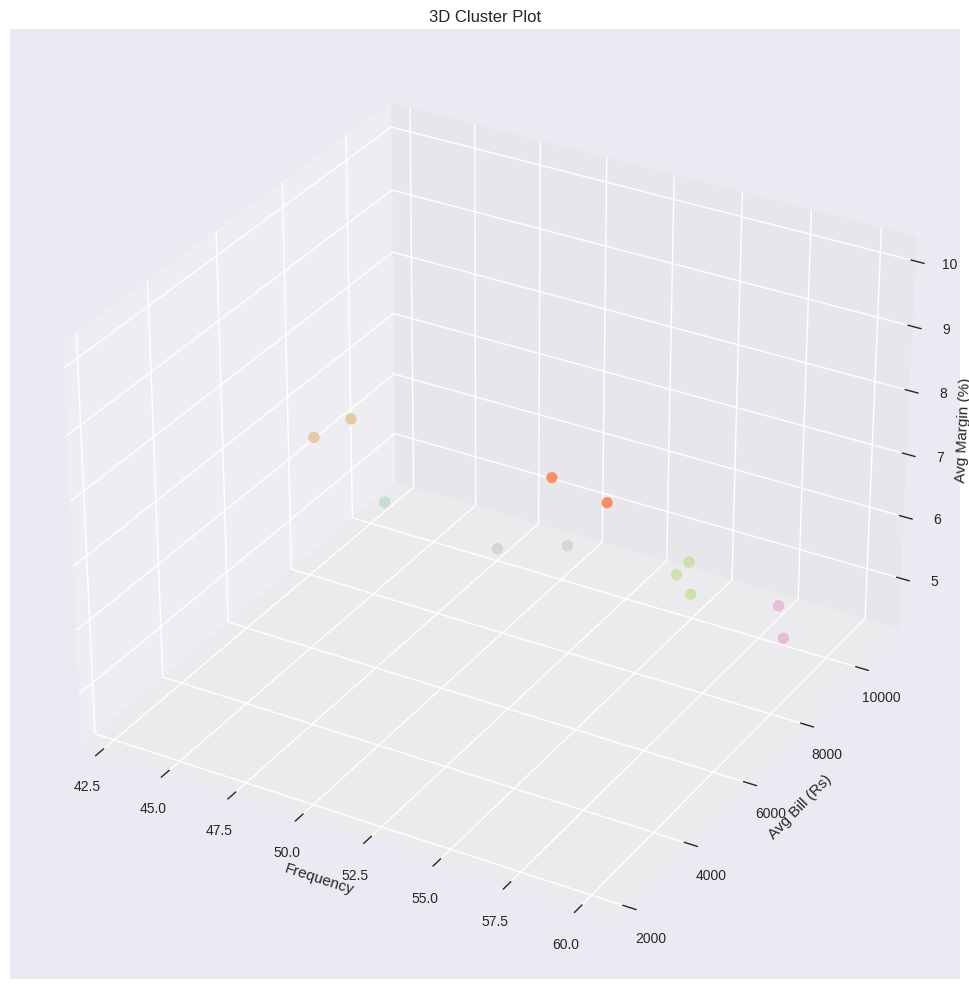

GREEN cluster: High Freq (55+) + Low Bill ✓ → Retail, BLUE cluster: High Freq + High Bill ✓ → VIP Wholesale, GREY: Low Freq (47) ✓ → Occasional


In [103]:
# 3D visualization: frequency, avg_bill, avg_margin_pct
# ---------------------------
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(cust['frequency'], cust['avg_bill'], cust['avg_margin_pct'], c=cust['cluster'], cmap='Set2', s=60)
ax.set_xlabel('Frequency')
ax.set_ylabel('Avg Bill (Rs)')
ax.set_zlabel('Avg Margin (%)')
plt.title('3D Cluster Plot')
plt.show()
print("GREEN cluster: High Freq (55+) + Low Bill ✓ → Retail, BLUE cluster: High Freq + High Bill ✓ → VIP Wholesale, GREY: Low Freq (47) ✓ → Occasional")

ABC


In [104]:
# Aggregate revenue per product by Product_Type
revenue_per_product = df.groupby("Product_Type")['Total_Sale_Value_Rs'].sum().sort_values(ascending=False)
total_revenue = revenue_per_product.sum()

# Calculate cumulative percentage
cum_revenue = revenue_per_product.cumsum()
cum_percent = 100 * cum_revenue / total_revenue

# Create the ABC DataFrame
abc_df = pd.DataFrame({
    "Revenue": revenue_per_product,
    "Cumulative_Revenue": cum_revenue,
    "Cumulative_Percent": cum_percent
})


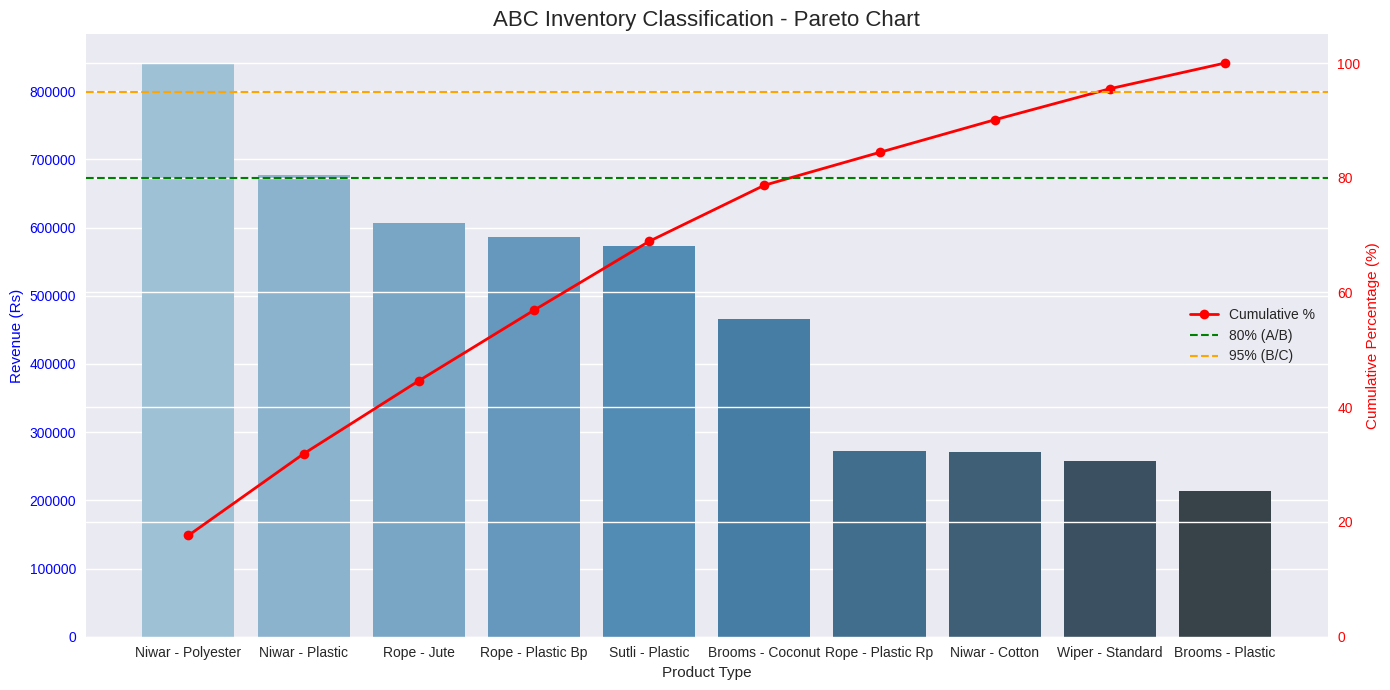

In [105]:
# --- Step 2: Generate the Plot (Visualization) ---
plt.figure(figsize=(14, 7))

# 1. Create the primary axis (ax1) for the Revenue Bars
ax1 = sns.barplot(
    x=abc_df.index,
    y=abc_df['Revenue'],
    palette="Blues_d",
    ax=plt.gca()
)

# 2. Create a secondary axis (ax2, twinx) for the Cumulative Percentage Line
ax2 = ax1.twinx()
ax2.plot(
    ax1.get_xticks(),
    abc_df['Cumulative_Percent'],
    color='red',
    marker='o',
    linestyle='-',
    linewidth=2,
    label='Cumulative %'
)

# --- 3. Add Threshold Lines ---
# A/B Threshold (80%)
ax2.axhline(
    80,
    color='green',
    linestyle='--',
    linewidth=1.5,
    label='80% (A/B)'
)

# B/C Threshold (95%)
ax2.axhline(
    95,
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label='95% (B/C)'
)

# --- 4. Formatting and Labels ---
# Axis 1 (Revenue) Labels
ax1.set_xlabel("Product Type")
ax1.set_ylabel('Revenue (Rs)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Rotate X labels for readability (Applied to the main plt context)
plt.xticks(rotation=45, ha='right')

# Axis 2 (Cumulative %) Labels
ax2.set_ylabel('Cumulative Percentage (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105) # Set Y-limit to show 100% clearly

# Title and Legend (combined from both axes)
plt.title('ABC Inventory Classification - Pareto Chart', fontsize=16)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='center right')

plt.tight_layout()
plt.show()

In [106]:
# --- Step 5: Add Rank, % Contribution, ABC Category ---

# Rank
abc_df['Rank'] = range(1, len(abc_df) + 1)

# % Contribution
abc_df['Percent_Contribution'] = abc_df['Revenue'] / total_revenue * 100

# ABC Category Assignment
def classify_abc(cum_pct):
    if cum_pct <= 80:
        return 'A'
    elif cum_pct <= 95:
        return 'B'
    else:
        return 'C'


        A_count = (abc_df['ABC_Category'] == 'A').sum()
        B_count = (abc_df['ABC_Category'] == 'B').sum()
        C_count = (abc_df['ABC_Category'] == 'C').sum()

# ABC Classification
abc_df['ABC_Category'] = abc_df['Cumulative_Percent'].apply(classify_abc)

# Reorder Columns
abc_df = abc_df[[
    "Rank",
    "Revenue",
    "Percent_Contribution",
    "Cumulative_Revenue",
    "Cumulative_Percent",
    "ABC_Category"
]]

print("\n===== ABC Ranking Table =====\n")
print(abc_df)

# --- Step 6: ABC Category Counts ---
abc_counts = abc_df['ABC_Category'].value_counts().sort_index()
print("\n===== ABC Category Counts =====\n")
print(abc_counts)

# --- Step 7: Revenue Distribution by Category ---
abc_revenue_dist = abc_df.groupby("ABC_Category")['Revenue'].sum()
abc_revenue_dist_pct = 100 * abc_revenue_dist / total_revenue

print("\n===== ABC Revenue Distribution =====\n")
print(pd.DataFrame({
    "Revenue (Rs)": abc_revenue_dist,
    "Revenue %": abc_revenue_dist_pct
}))



===== ABC Ranking Table =====

                   Rank  Revenue  Percent_Contribution  Cumulative_Revenue  \
Product_Type                                                                 
Niwar - Polyester     1   841388             17.657470              841388   
Niwar - Plastic       2   677868             14.225820             1519256   
Rope - Jute           3   606579             12.729740             2125835   
Rope - Plastic Bp     4   585821             12.294110             2711656   
Sutli - Plastic       5   572309             12.010546             3283965   
Brooms - Coconut      6   465775              9.774811             3749740   
Rope - Plastic Rp     7   272857              5.726210             4022597   
Niwar - Cotton        8   270854              5.684175             4293451   
Wiper - Standard      9   258047              5.415406             4551498   
Brooms - Plastic     10   213556              4.481712             4765054   

                   Cumulative_P

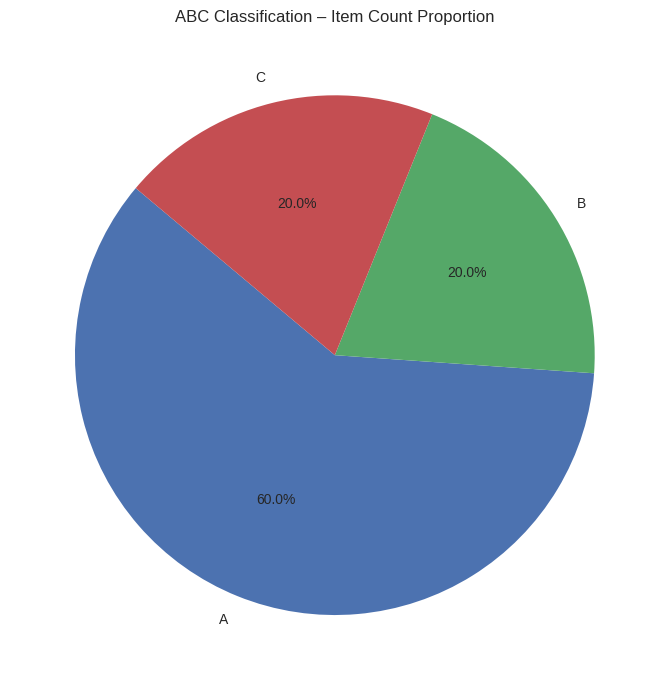

In [107]:
# ----- PIE CHART: Item Count Proportion -----
plt.figure(figsize=(7,7))
plt.pie(
    abc_counts.values,
    labels=abc_counts.index,
    autopct="%1.1f%%",
    startangle=140
)
plt.title("ABC Classification – Item Count Proportion")
plt.tight_layout()
plt.show()



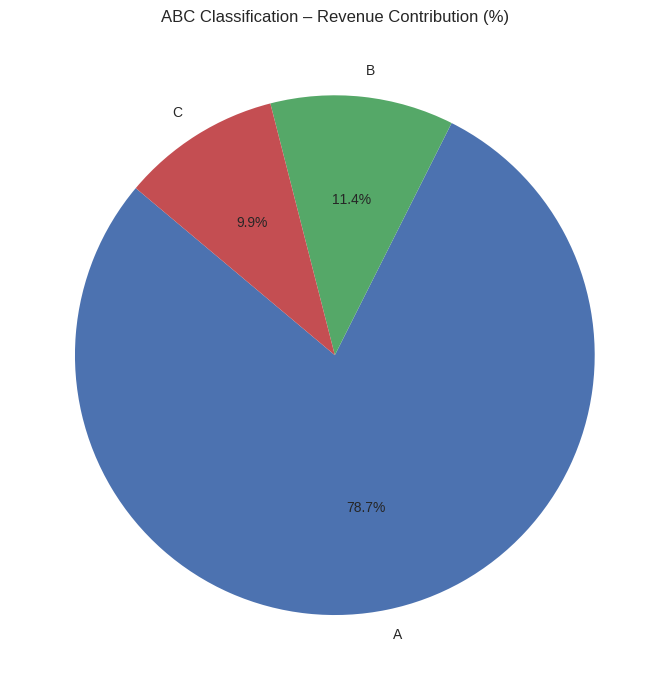

In [108]:
# OPTIONAL: Revenue Contribution Pie Chart
plt.figure(figsize=(7,7))
plt.pie(
    abc_revenue_dist_pct.values,
    labels=abc_revenue_dist_pct.index,
    autopct="%1.1f%%",
    startangle=140
)
plt.title("ABC Classification – Revenue Contribution (%)")
plt.tight_layout()
plt.show()

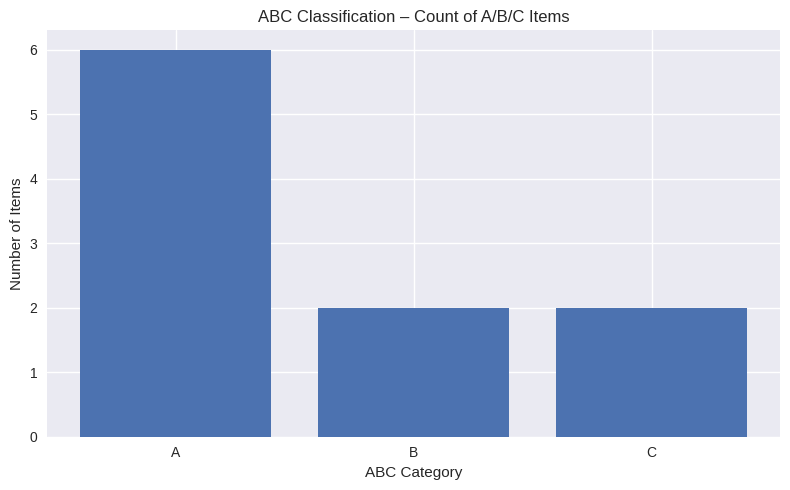

In [109]:
# ----- BAR CHART: Item Counts -----
plt.figure(figsize=(8,5))
plt.bar(abc_counts.index, abc_counts.values)
plt.xlabel("ABC Category")
plt.ylabel("Number of Items")
plt.title("ABC Classification – Count of A/B/C Items")
plt.tight_layout()
plt.show()


Profit margin and Revenue analysis

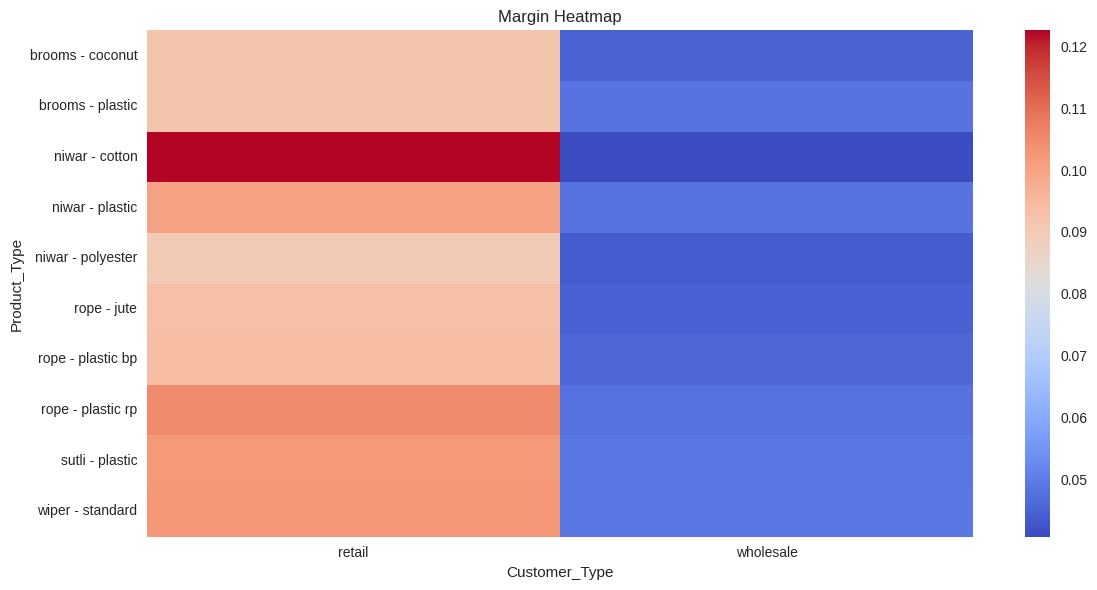

In [110]:
pivot = df_clean.pivot_table(values="Margin",
                             index="Product_Type",
                             columns="Customer_Type",
                             aggfunc="mean")

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="coolwarm", annot=False)
plt.title("Margin Heatmap")
plt.show()

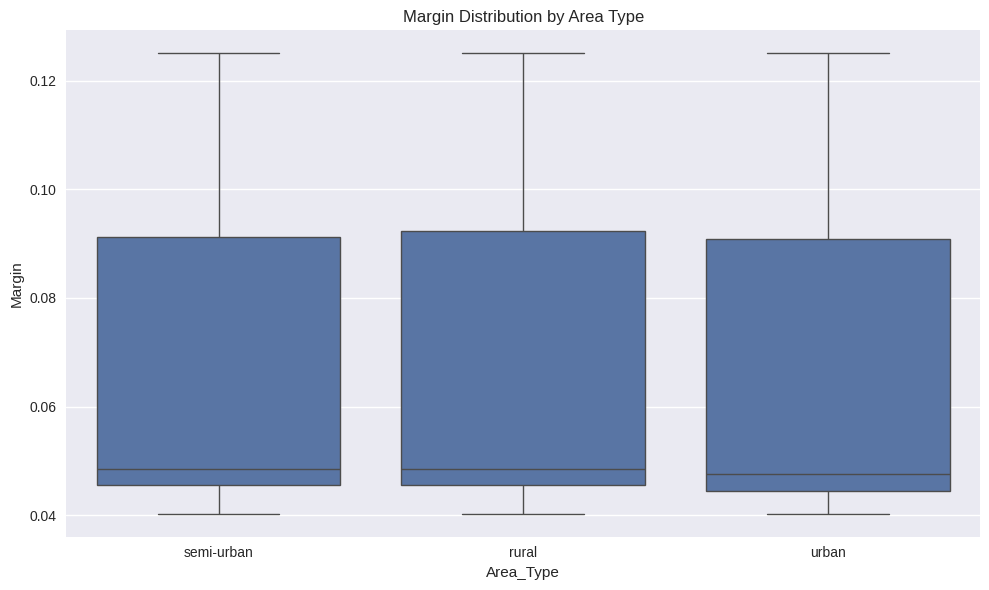

In [111]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean, x="Area_Type", y="Margin")
plt.title("Margin Distribution by Area Type")
plt.show()


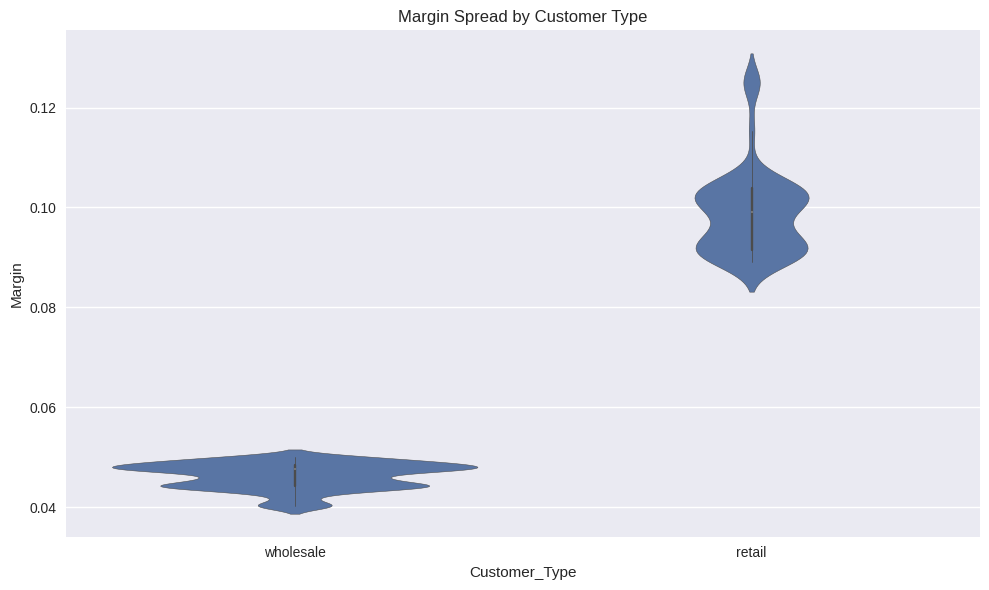

In [112]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df_clean, x="Customer_Type", y="Margin")
plt.title("Margin Spread by Customer Type")
plt.show()
